In [20]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_basket_difference(
    file_path,
    side1_products,
    side1_scalars,
    side2_products,
    side2_scalars,
    title="Basket Premium / Difference vs Timestamp",
):
    """
    For each timestamp:
        sum(side1_product_mid_price * scalar) - sum(side2_product_mid_price * scalar)

    Parameters
    ----------
    file_path : str
        Path to r2_d-1.csv
    side1_products : sequence[str]
        Products on the first side
    side1_scalars : sequence[int | float]
        Matching scalars for side1_products
    side2_products : sequence[str]
        Products on the second side
    side2_scalars : sequence[int | float]
        Matching scalars for side2_products
    """

    if len(side1_products) != len(side1_scalars):
        raise ValueError("side1_products and side1_scalars must have the same length")
    if len(side2_products) != len(side2_scalars):
        raise ValueError("side2_products and side2_scalars must have the same length")

    df = pd.read_csv(file_path, sep=";")

    # Clean numeric columns
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
    df = df.dropna(subset=["timestamp", "product", "mid_price"])

    # Build a pivot table: rows = timestamp, columns = product, values = mid_price
    # If there are duplicates for a timestamp/product, take the last observed value.
    pivot = df.pivot_table(
        index="timestamp",
        columns="product",
        values="mid_price",
        aggfunc="last",
    ).sort_index()

    # Compute weighted sums for each side
    side1_value = pd.Series(0.0, index=pivot.index)
    for product, scalar in zip(side1_products, side1_scalars):
        if product not in pivot.columns:
            raise KeyError(f"Product '{product}' not found in market file")
        side1_value = side1_value + pivot[product].fillna(0) * scalar

    side2_value = pd.Series(0.0, index=pivot.index)
    for product, scalar in zip(side2_products, side2_scalars):
        if product not in pivot.columns:
            raise KeyError(f"Product '{product}' not found in market file")
        side2_value = side2_value + pivot[product].fillna(0) * scalar

    difference = side1_value - side2_value
    print("Mean of", difference.mean())

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(difference.index, difference.values, linewidth=0.8)
    plt.axhline(difference.mean(), linestyle="--", linewidth=0.8)
    plt.title(title)
    plt.xlabel("Timestamp")
    plt.ylabel("Price Difference")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return difference

FIRST HALF
---
Mean of 70.0449


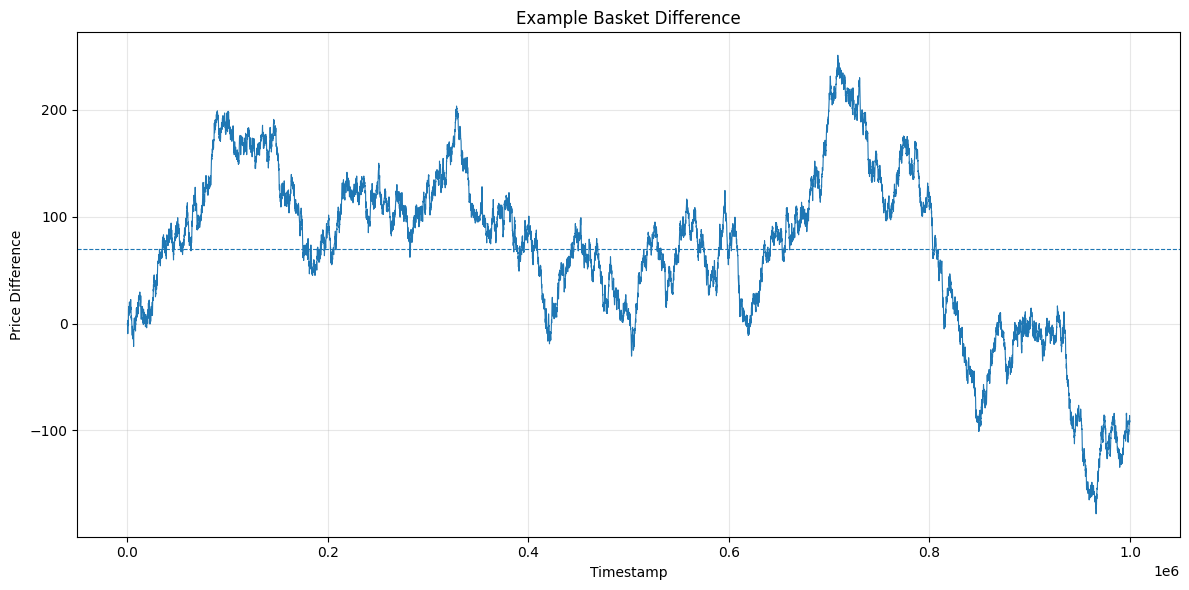

Mean of 43.9226


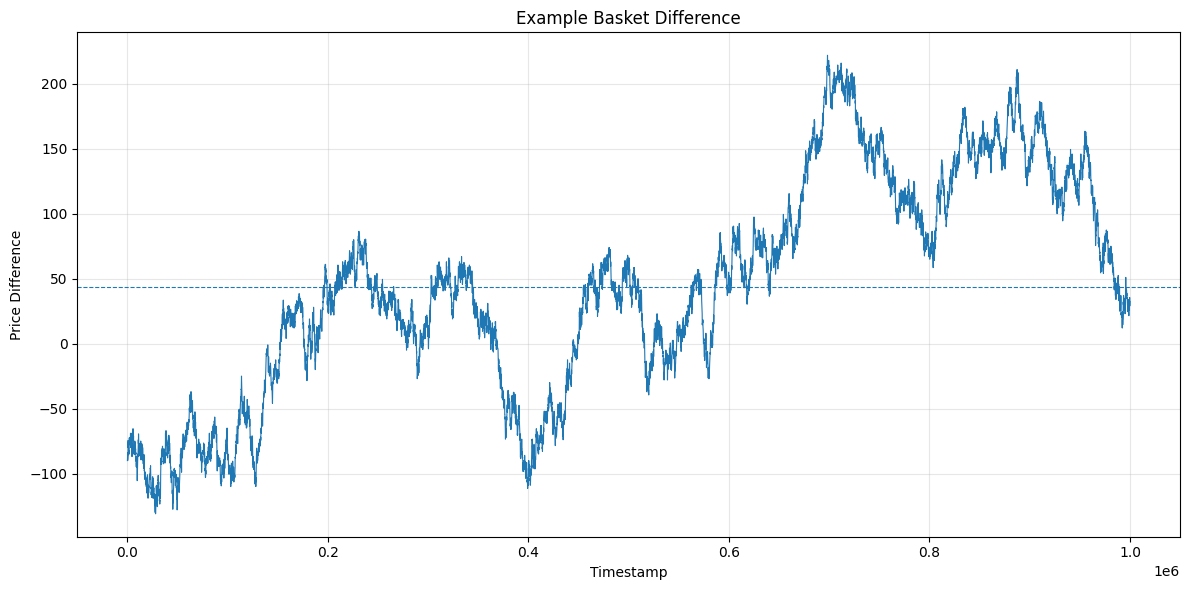

Mean of 32.3198


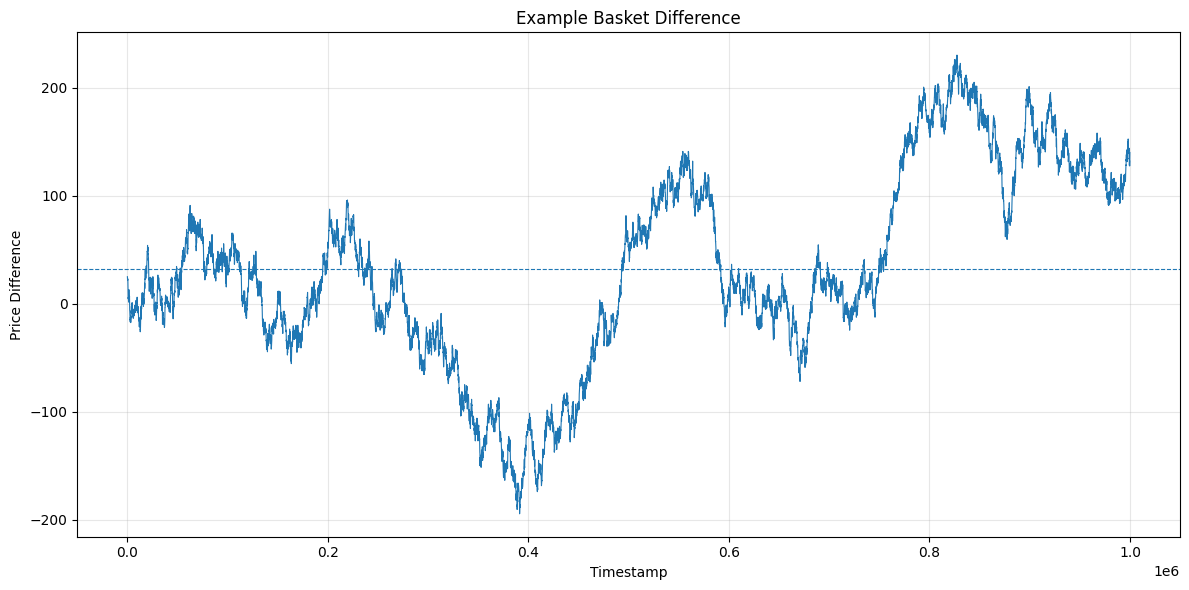

SECOND HALF
---
Mean of 58.0801


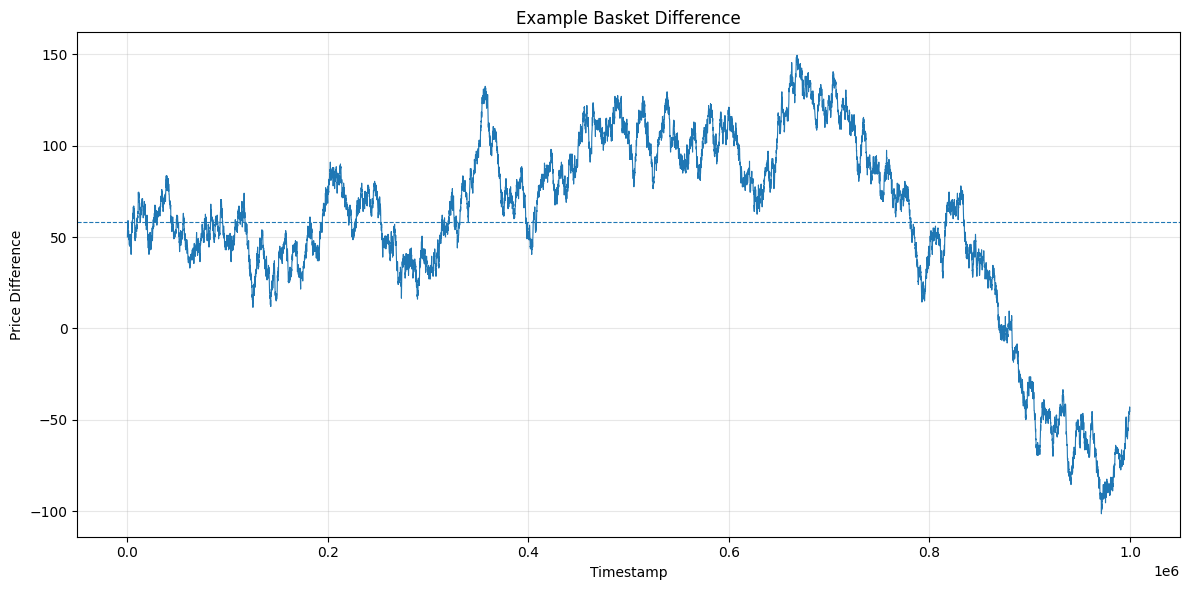

Mean of -3.83915


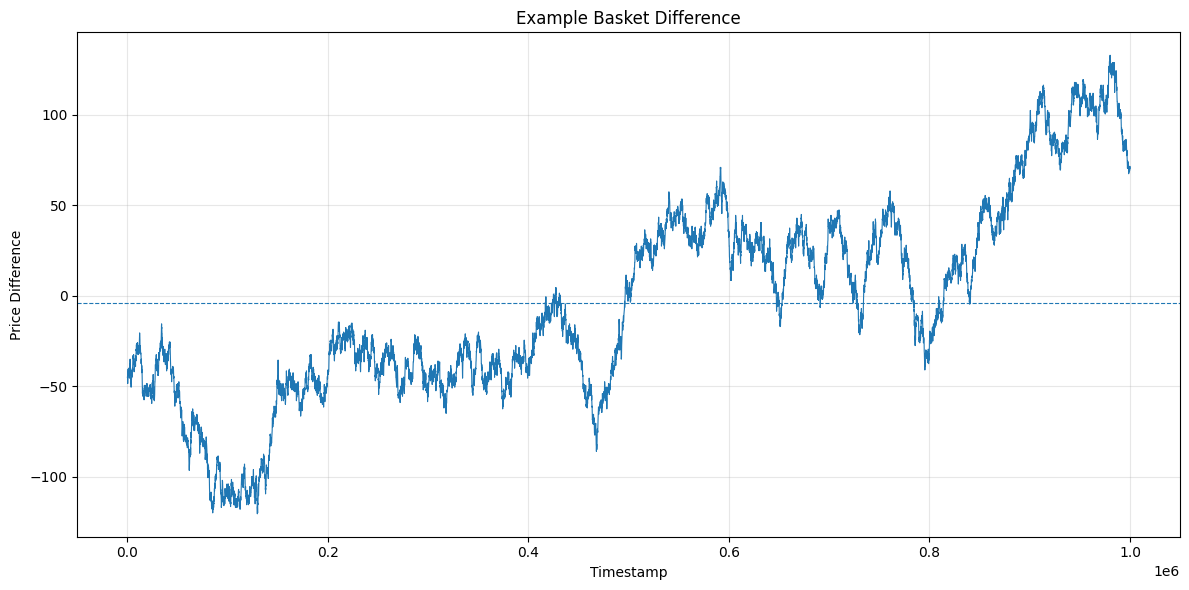

Mean of 36.46695


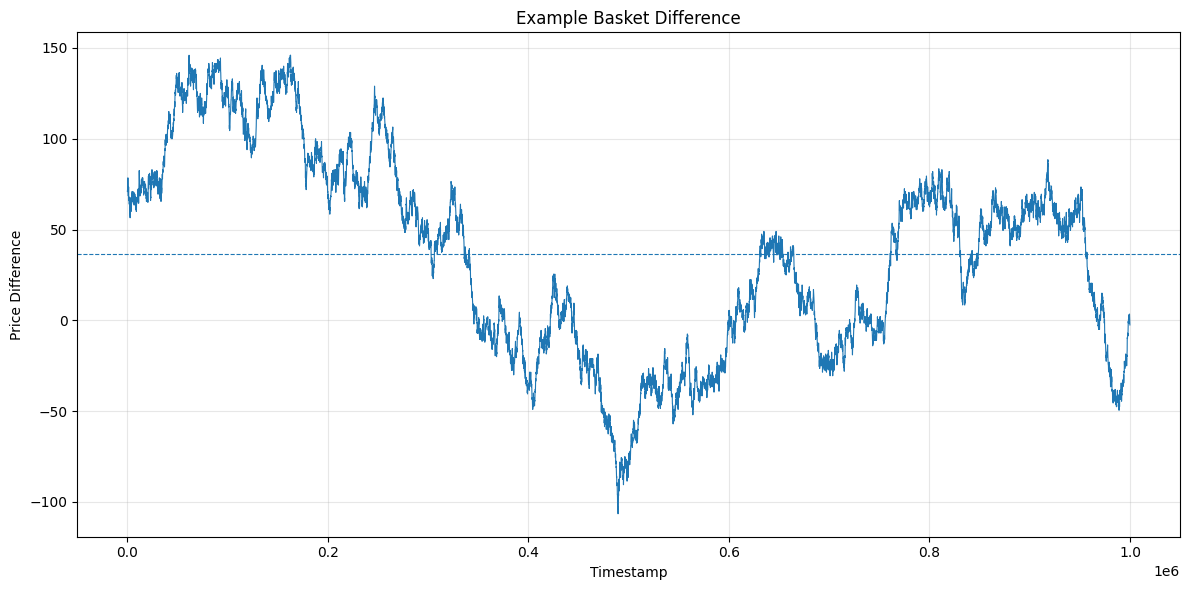

TESTING FIRST + SECOND
---
Mean of 11.9648


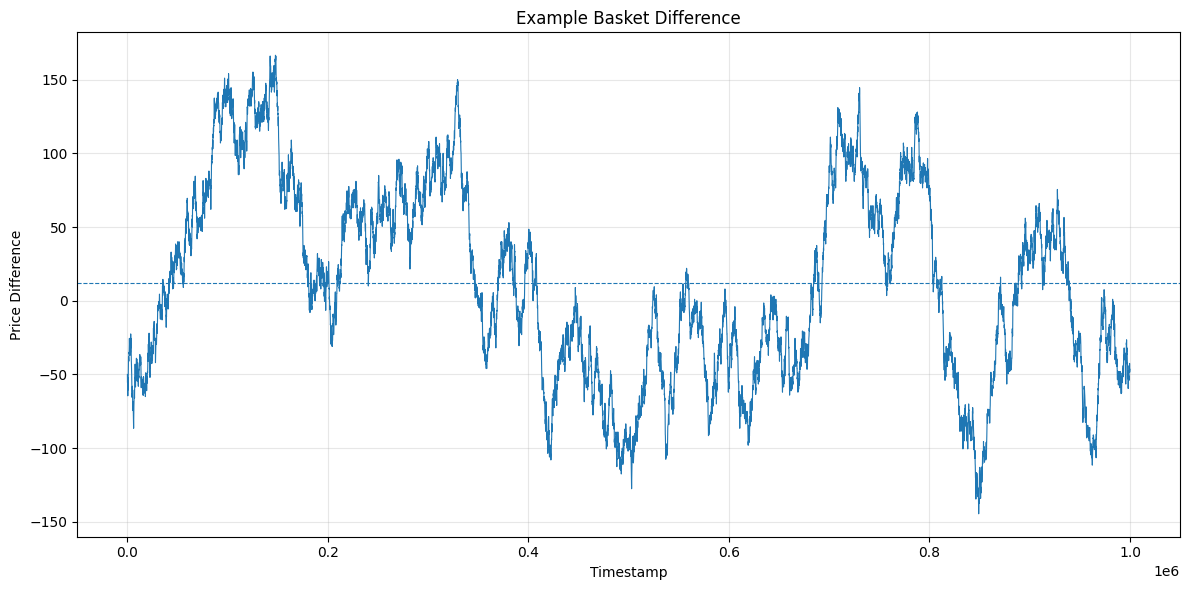

Mean of 47.76175


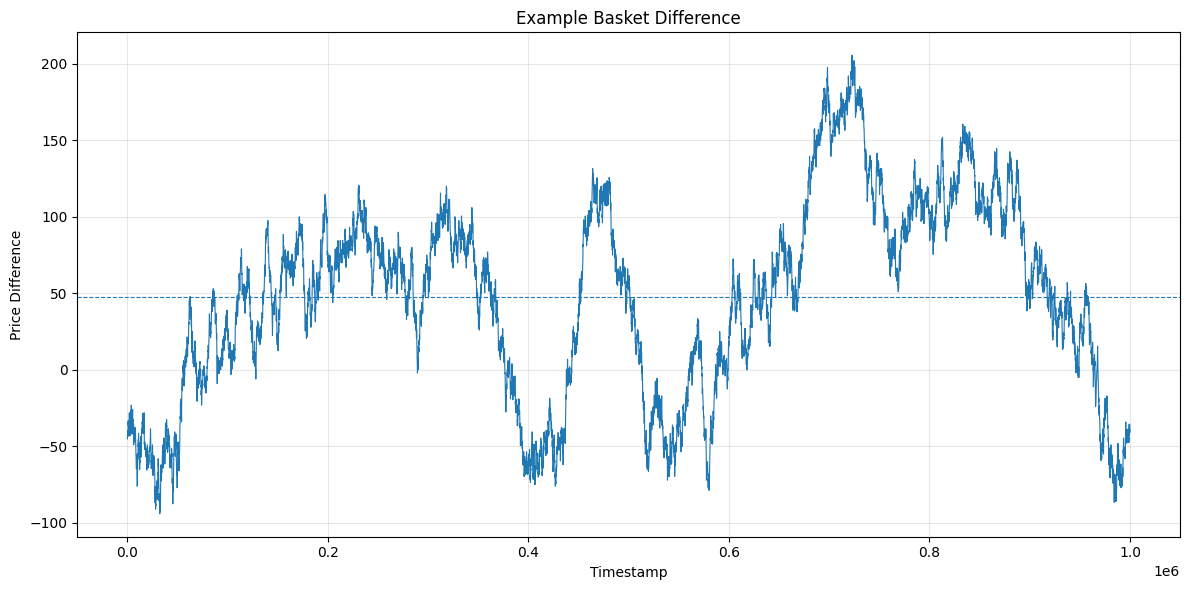

Mean of -4.14715


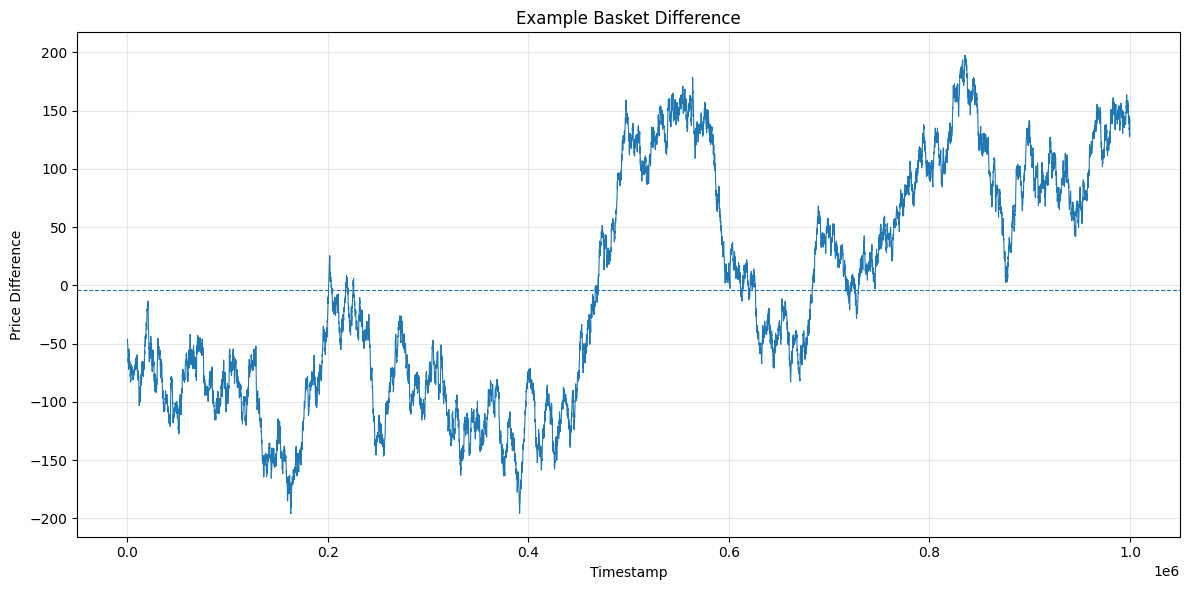

In [28]:
# Example usage:
print("FIRST HALF")
print("---")
for day in range(-1, 2):
    file_path = "r2_d" + str(day) + ".csv"
    side1_products = ["PICNIC_BASKET1"]
    side1_scalars = [1]
    side2_products = ["CROISSANTS", "JAMS", "DJEMBES"]
    side2_scalars = [6, 3, 1]
    diff_series = plot_basket_difference(
        file_path,
        side1_products,
        side1_scalars,
        side2_products,
        side2_scalars,
        title="Example Basket Difference",
    )

print("SECOND HALF")
print("---")
for day in range(-1, 2):
    file_path = "r2_d" + str(day) + ".csv"
    side1_products = ["PICNIC_BASKET2"]
    side1_scalars = [1]
    side2_products = ["CROISSANTS", "JAMS"]
    side2_scalars = [4, 2]
    diff_series = plot_basket_difference(
        file_path,
        side1_products,
        side1_scalars,
        side2_products,
        side2_scalars,
        title="Example Basket Difference",
    )

print("TESTING FIRST + SECOND")
print("---")
for day in range(-1, 2):
    file_path = "r2_d" + str(day) + ".csv"
    side1_products = ["PICNIC_BASKET1"]
    side1_scalars = [1]
    side2_products = ["PICNIC_BASKET2", "CROISSANTS", "JAMS", "DJEMBES"]
    side2_scalars = [1, 2, 1, 1]
    diff_series = plot_basket_difference(
        file_path,
        side1_products,
        side1_scalars,
        side2_products,
        side2_scalars,
        title="Example Basket Difference",
    )

